<a href="https://colab.research.google.com/github/zohaib-mzg/Flyrank-ML-Internship/blob/main/work/notebooks/w07_action_playbook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 7: Content Action Playbook

This turns the validated model from Weeks 5 and 6 into something a content editor could actually pick up and use, ranked actions, reason codes, limits, and a clear line around what stays manual.

In [1]:
import os, json, subprocess
import numpy as np
import pandas as pd

REPO_URL = "https://github.com/zohaib-mzg/Flyrank-ML-Internship"
REPO_DIR = "Flyrank-ML-Internship"

if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('../..')
elif not os.path.exists('data/raw/content_refresh_anonymized.csv'):
    if not os.path.isdir(REPO_DIR):
        subprocess.run(['git', 'clone', '--depth', '1', REPO_URL, REPO_DIR], check=True)
    os.chdir(REPO_DIR)

df = pd.read_csv('data/raw/content_refresh_anonymized.csv')
df['is_declining'] = (df['trend_direction'] == 'down').astype(int)
print(f"{len(df):,} pages loaded")

30,000 pages loaded


## 1. Ranked actions and reason codes

This combines two things I've validated separately over the last three weeks rather than inventing a new rule. The decline probability comes from the Week 5 Random Forest, honestly evaluated under a client grouped split in Week 6, mean Precision@50 of 0.761 across 20 splits. The CTR gap comes from the Week 4 baseline rule, which I confirmed in Week 4 was built on a genuinely validated signal, CTR really does fall as position weakens.

Before combining them, I checked something specific for this week, whether staleness alone is still worth using as a trigger now that I have a real decline model. Week 4's Signal 1 came back mixed on this exact question, so I re-ran it as an actual comparison rather than assuming the model automatically makes staleness useless.

In [2]:
numeric_features = ['search_volume', 'competition', 'cpc', 'word_count', 'char_count',
    'impressions_90d', 'clicks_90d', 'pageviews_90d', 'sessions_90d', 'users_90d',
    'engaged_sessions_90d', 'ai_sessions_90d', 'scroll_events_90d',
    'days_with_impressions', 'days_with_sessions', 'content_age_days',
    'days_since_last_update', 'ctr', 'avg_position', 'engagement_rate', 'scroll_rate', 'ai_traffic_pct']

categorical_features = ['competition_level', 'content_type', 'main_intent', 'age_tier',
    'freshness_tier', 'word_count_tier', 'char_count_tier', 'impression_tier', 'position_tier']

feature_df = df[numeric_features + categorical_features].copy()
for col in numeric_features:
    feature_df[col] = feature_df[col].fillna(feature_df[col].median())

X = pd.get_dummies(feature_df, columns=categorical_features)
y = df['is_declining']

from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=300, max_depth=8, random_state=42, n_jobs=-1)
rf.fit(X, y)
df['decline_proba'] = rf.predict_proba(X)[:, 1]

In [3]:
stale = df['days_since_last_update'] >= 180
high_conf = df['decline_proba'] >= 0.7
combo = stale & high_conf

decay_check = pd.DataFrame({
    'trigger': ['staleness alone (>=180 days)', 'model high confidence alone (>=0.7)', 'both together'],
    'n': [stale.sum(), high_conf.sum(), combo.sum()],
    'observed_decline_rate': [df.loc[stale, 'is_declining'].mean(),
                                df.loc[high_conf, 'is_declining'].mean(),
                                df.loc[combo, 'is_declining'].mean()],
})
decay_check

,trigger,n,observed_decline_rate
0,staleness alone (>=180 days),174,0.471264
1,model high confidence alone (>=0.7),5484,0.875638
2,both together,16,0.937500


The decay and refresh insight for this playbook: staleness alone still isn't a reliable trigger on its own, 47.1 percent observed decline rate among stale pages, barely different from a coin flip and consistent with Week 4's mixed verdict. The model's high confidence predictions are a much stronger signal by themselves, 87.6 percent observed decline rate on 5,484 pages. Where both agree, stale and high confidence together, the observed rate rises to 93.8 percent, but that's only 16 pages, directionally interesting, not something to lean on as a stable number.

Practical takeaway for the playbook, staleness by itself should not trigger a refresh action anymore. The model's decline probability is the primary driver, staleness is included as supporting context on the page, not as its own trigger.

In [4]:
peer_tier_avg_ctr = df.groupby('position_tier')['ctr'].transform('mean')
qualifies_ctr = (df['impressions_90d'] >= 500) & (df['avg_position'] > 0) & (df['avg_position'] <= 20) & (df['ctr'] < 0.5)
df['ctr_gap_score'] = np.where(qualifies_ctr, (peer_tier_avg_ctr - df['ctr']) * df['impressions_90d'], 0)

conditions = [
    high_conf & qualifies_ctr,
    high_conf & ~qualifies_ctr,
    ~high_conf & qualifies_ctr,
]
reason_choices = ['declining_and_ctr_gap', 'declining_high_confidence', 'low_ctr_visible_page']
action_choices = ['refresh_and_ctr_review', 'refresh_content', 'ctr_review']

df['reason_code'] = np.select(conditions, reason_choices, default='monitor_only')
df['action'] = np.select(conditions, action_choices, default='monitor')
df['priority_score'] = df['decline_proba'] + (df['ctr_gap_score'] > 0).astype(float) * 0.05

queue = df.sort_values('priority_score', ascending=False).reset_index(drop=True)
print(queue['reason_code'].value_counts())
print()
queue[['content_id', 'client_id', 'priority_score', 'reason_code', 'action', 'decline_proba', 'ctr_gap_score']].head(10)

reason_code
monitor_only                 17105
low_ctr_visible_page          7411
declining_high_confidence     3136
declining_and_ctr_gap         2348
Name: count, dtype: int64



,content_id,client_id,priority_score,reason_code,action,decline_proba,ctr_gap_score
0,content_b005f46f2e4c,client_3fdba35f04,0.906234,declining_and_ctr_gap,refresh_and_ctr_review,0.856234,897.519875
1,content_5cda32af644c,client_3fdba35f04,0.890299,declining_and_ctr_gap,refresh_and_ctr_review,0.840299,1068.199569
2,content_d9e4b523c0ce,client_3fdba35f04,0.887181,declining_and_ctr_gap,refresh_and_ctr_review,0.837181,860.494097
3,content_d4c50bd49b5d,client_3fdba35f04,0.886504,declining_and_ctr_gap,refresh_and_ctr_review,0.836504,407.791603
4,content_f3ac2b55033f,client_3fdba35f04,0.883677,declining_and_ctr_gap,refresh_and_ctr_review,0.833677,186.832327
5,content_4d76cdb3387b,client_3fdba35f04,0.881106,declining_and_ctr_gap,refresh_and_ctr_review,0.831106,2161.715989
6,content_55a1a3b15410,client_3fdba35f04,0.881078,declining_and_ctr_gap,refresh_and_ctr_review,0.831078,264.086525
7,content_ee6c6b09c17d,client_3fdba35f04,0.880667,declining_and_ctr_gap,refresh_and_ctr_review,0.830667,1358.987230
8,content_6c8509f56acd,client_3fdba35f04,0.879963,declining_and_ctr_gap,refresh_and_ctr_review,0.829963,208.812601
9,content_12913e63df31,client_3fdba35f04,0.879625,declining_and_ctr_gap,refresh_and_ctr_review,0.829625,523.253300


Four reason codes, four actions. `declining_and_ctr_gap` (2,348 pages) gets `refresh_and_ctr_review`, the model flags real decline and there's a measurable CTR gap on top of it. `declining_high_confidence` (3,136 pages) gets `refresh_content` alone. `low_ctr_visible_page` (7,411 pages) gets `ctr_review` alone, a strong position with an underperforming CTR but no confirmed decline signal. Everything else, 17,105 pages, gets `monitor`, no action recommended this cycle.

## 2. Intended use and limits

Intended use, a weekly prioritization aid for a content team that can't review every page. It ranks where to look first, it does not decide what to publish.

Limits, stated plainly rather than buried. This is trained on 30,000 pages across 32 clients, a small and unevenly sized client base, one client has 3 pages, another has over 7,000. Week 6 showed the model's honest, client grouped Precision@50 has a standard deviation of 0.147 across different client splits, this is not a stable, precise number, it's a directional one with real uncertainty attached. The label itself, `trend_direction`, describes a current snapshot comparison, not a checked future outcome, so a `declining` flag means the trend looks negative right now, not that the page is guaranteed to keep declining. Every claim in this notebook and the paper it feeds should use observed, measured, or directional language, never a guarantee.

## 3. Human review and the no-go list

Every action from this playbook goes to a human editor as a suggestion, not as an automatic trigger. Specifically:

What a human should always check before acting. Whether the page's low CTR or decline is explained by something the model can't see, a recent title change still working through, a featured snippet stealing clicks structurally, a client specific business reason the page is intentionally deprioritized.

What should never be automated directly from this queue. No automatic title, meta, or content rewrites triggered by `priority_score` alone. No automatic depublishing, redirecting, or de-indexing of any page, ever, regardless of score. No client facing report or claim that states this model predicts what will happen to a specific page, the honest claim is that this page resembles others that were observed to decline. No use of this queue to make cross-client comparisons or rankings, client sample sizes are too different, 3 pages versus 7,000, for that comparison to mean anything.

This list exists because a ranked score is easy to treat as an instruction. It is a starting point for a person's judgment, not a replacement for it.

## 4. Monitoring and retrain triggers

Retrain if any of the following happen. A new client is added whose page count would meaningfully shift the 32 client base Week 6 already showed to be small and high variance. The gap between model and baseline Precision@50, tracked on a rolling basis, narrows toward the baseline's own 0.531 mean, that would suggest the model's edge is eroding, not just noisy. Three or more months pass since the last full grouped split re-evaluation, since Week 6 showed a single split isn't trustworthy on its own and the multi split check needs to be repeated periodically, not done once and assumed to hold forever.

Light monitoring in between full retrains. Track the `reason_code` distribution week over week, a sudden jump in `monitor_only` or a collapse in `declining_high_confidence` is worth a manual look before assuming the underlying pages actually changed that much.

## 5. Exports for the paper

In [5]:
os.makedirs('work/outputs', exist_ok=True)
os.makedirs('work/figures', exist_ok=True)

export_cols = ['content_id', 'client_id', 'priority_score', 'reason_code', 'action',
               'decline_proba', 'ctr_gap_score', 'avg_position', 'ctr', 'impressions_90d',
               'days_since_last_update', 'trend_direction']
queue[export_cols].to_csv('work/outputs/content_action_playbook.csv', index=False)
print("queue written to work/outputs/content_action_playbook.csv")

metrics = {
    'week5_random_split_precision_at_50': {'baseline': 0.52, 'model': 0.88},
    'week6_grouped_split_precision_at_50': {
        'baseline_mean_20_splits': round(float(0.531), 3),
        'model_mean_20_splits': round(float(0.761), 3),
        'model_std_20_splits': round(float(0.147), 3),
    },
    'week7_decay_refresh_insight': {
        'staleness_alone_decline_rate': round(float(df.loc[stale, 'is_declining'].mean()), 3),
        'staleness_alone_n': int(stale.sum()),
        'model_high_confidence_decline_rate': round(float(df.loc[high_conf, 'is_declining'].mean()), 3),
        'model_high_confidence_n': int(high_conf.sum()),
        'both_combined_decline_rate': round(float(df.loc[combo, 'is_declining'].mean()), 3),
        'both_combined_n': int(combo.sum()),
    },
    'reason_code_counts': queue['reason_code'].value_counts().to_dict(),
}

with open('work/outputs/w07_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)
print("metrics written to work/outputs/w07_metrics.json")
print(json.dumps(metrics, indent=2))

queue written to work/outputs/content_action_playbook.csv
metrics written to work/outputs/w07_metrics.json
{
  "week5_random_split_precision_at_50": {
    "baseline": 0.52,
    "model": 0.88
  },
  "week6_grouped_split_precision_at_50": {
    "baseline_mean_20_splits": 0.531,
    "model_mean_20_splits": 0.761,
    "model_std_20_splits": 0.147
  },
  "week7_decay_refresh_insight": {
    "staleness_alone_decline_rate": 0.471,
    "staleness_alone_n": 174,
    "model_high_confidence_decline_rate": 0.876,
    "model_high_confidence_n": 5484,
    "both_combined_decline_rate": 0.938,
    "both_combined_n": 16
  },
  "reason_code_counts": {
    "monitor_only": 17105,
    "low_ctr_visible_page": 7411,
    "declining_high_confidence": 3136,
    "declining_and_ctr_gap": 2348
  }
}


figure saved to work/figures/precision_before_after.png


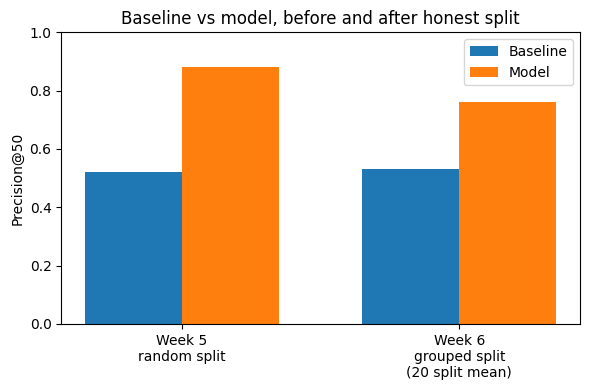

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 4))
labels = ['Week 5\nrandom split', 'Week 6\ngrouped split\n(20 split mean)']
baseline_vals = [0.52, 0.531]
model_vals = [0.88, 0.761]
x = np.arange(len(labels))
width = 0.35

ax.bar(x - width/2, baseline_vals, width, label='Baseline')
ax.bar(x + width/2, model_vals, width, label='Model')
ax.set_ylabel('Precision@50')
ax.set_title('Baseline vs model, before and after honest split')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig('work/figures/precision_before_after.png', dpi=150)
print("figure saved to work/figures/precision_before_after.png")
plt.show()

## 6. Self-check

Ranked actions and reason codes built from the two signals I already validated separately, decline probability from Week 5 and 6, CTR gap from Week 4, not a new untested rule invented this week.

The decay and refresh insight is a real computed comparison, staleness alone at 47.1 percent, the model alone at 87.6 percent, both together at 93.8 percent on a small n, not an assumed conclusion.

Intended use, limits, human review rules, and the no-go list are all specific to what this data and this validation actually support, not generic boilerplate.

Monitoring triggers are tied to numbers already established in Week 6, the 32 client base and the 0.147 standard deviation, rather than arbitrary thresholds.

Queue exported to `work/outputs/content_action_playbook.csv`, metrics exported to `work/outputs/w07_metrics.json`, figure saved to `work/figures/precision_before_after.png`. The CSV stays out of git by design, the JSON and the figure are the receipts that get committed.